# M3-B1 — Exploration des 3 sources Acerox

> Notebook d'**exploration rapide** — pas d'EDA fouillée, juste assez pour
> remplir l'inventaire de la note d'identification.

Auteur·rice : `<prénom>` — Date : `<date>`

**Règles** :
- Pas de transformation (juste lecture, `info`, `head`, `describe`)
- Une cellule markdown par source — qu'est-ce que tu observes ?
- Trace les **risques** et **questions** qui émergent pour l'`identification_sources.md`

In [9]:
from pathlib import Path
import json

import pandas as pd

DATA_DIR = Path("../data")

## Source 1 — Capteurs IoT (CSV)

In [33]:
df_iot = pd.read_csv(DATA_DIR / "capteurs_iot.csv")
df_iot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      51000 non-null  object 
 1   site           51000 non-null  object 
 2   line_id        51000 non-null  int64  
 3   sensor_id      51000 non-null  object 
 4   temperature_c  51000 non-null  float64
 5   vibration_mms  50251 non-null  float64
 6   debit_uh       51000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 2.7+ MB


In [56]:

# Aperçu des premières lignes
display(df_iot.head())

# Statistiques descriptives
display(df_iot.describe())

# Valeurs manquantes
print("=== Valeurs manquantes ===")
print(df_iot.isnull().sum())

# Répartition par site
print("\n=== Occurrences par site ===")
print(df_iot["site"].value_counts())

# Répartition par line_id
print("\n=== Occurrences par line_id ===")
print(df_iot["line_id"].value_counts())

# Période couverte
print(f"\nPériode : {df_iot['timestamp'].min()}  →  {df_iot['timestamp'].max()}")


,timestamp,site,line_id,sensor_id,temperature_c,vibration_mms,debit_uh
0,2026-04-14T19:21:43,Lyon,1,SLYO-L1-T01,77.92,5.539793,101.27
1,2026-04-27T02:47:12,Lyon,1,SLYO-L1-T01,70.58,3.361715,110.19
2,2026-04-13T18:18:50,Saint-Etienne,1,SSAI-L1-T01,62.37,4.019277,111.28
3,2026-04-05T10:34:03,Roubaix,2,SROU-L2-T01,66.17,4.922531,123.93
4,2026-04-20T10:18:07,Saint-Etienne,3,SSAI-L3-T01,55.56,1.643043,101.40


,line_id,temperature_c,vibration_mms,debit_uh
count,51000.000000,51000.000000,50251.000000,51000.000000
mean,2.005882,73.717034,4.831502,110.050188
std,1.033472,27.005577,2.685963,11.832749
min,1.000000,26.470000,0.000000,80.000000
25%,1.000000,60.237500,3.302777,102.000000
50%,2.000000,66.090000,4.187726,110.100000
75%,3.000000,72.840000,5.171534,118.050000
max,4.000000,160.000000,12.000000,150.000000


=== Valeurs manquantes ===
timestamp          0
site               0
line_id            0
sensor_id          0
temperature_c      0
vibration_mms    749
debit_uh           0
dtype: int64

=== Occurrences par site ===
site
Roubaix          20570
Saint-Etienne    20248
Lyon             10182
Name: count, dtype: int64

=== Occurrences par line_id ===
line_id
1    21980
3    12068
2    11846
4     5106
Name: count, dtype: int64

Période : 2026-04-01T00:00:38  →  2026-04-29T23:57:53


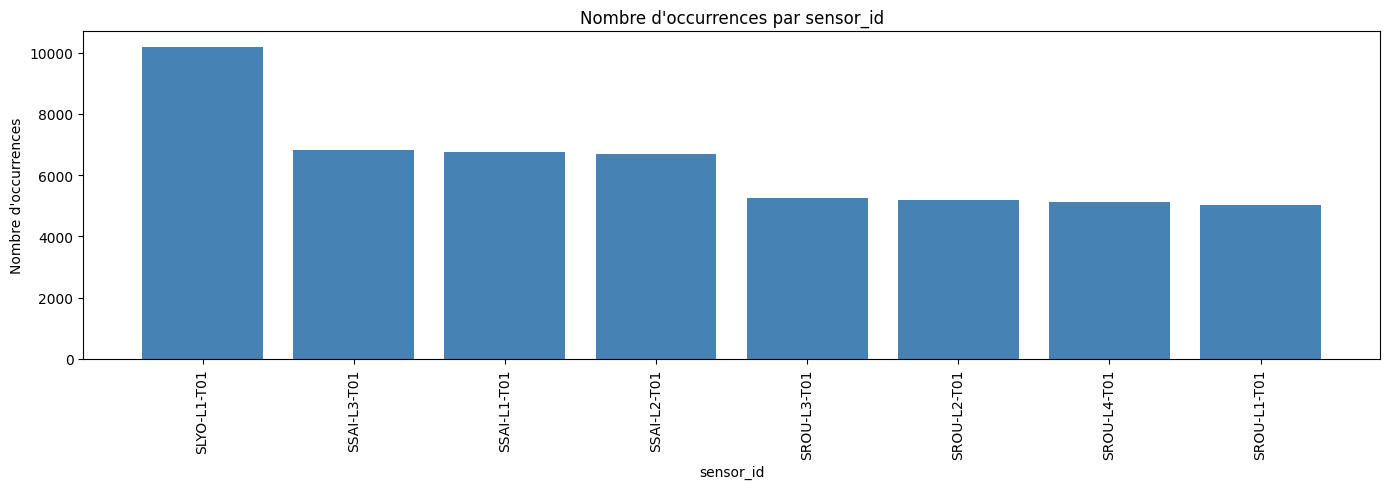

In [78]:

import matplotlib.pyplot as plt

# Graphique : nombre d'occurrences par sensor_id
counts_sensor = df_iot["sensor_id"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(counts_sensor.index, counts_sensor.values, color="steelblue")
ax.set_title("Nombre d'occurrences par sensor_id")
ax.set_xlabel("sensor_id")
ax.set_ylabel("Nombre d'occurrences")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


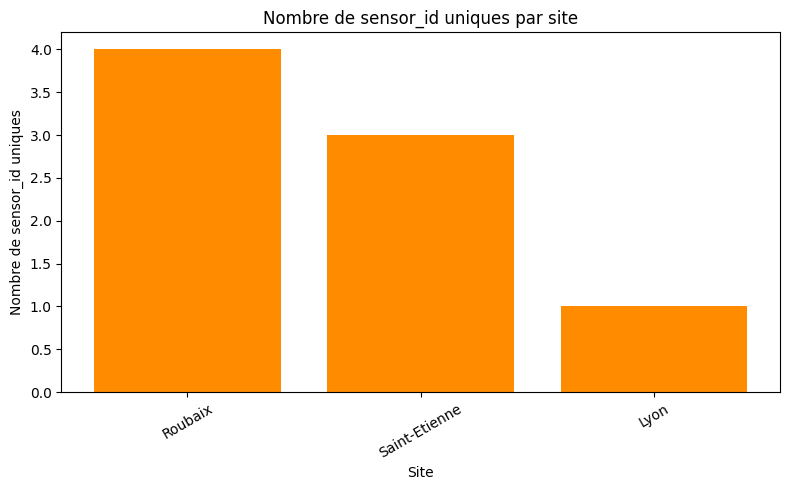

In [99]:

# Graphique : nombre de sensor_id uniques par site
sensors_per_site = df_iot.groupby("site")["sensor_id"].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sensors_per_site.index, sensors_per_site.values, color="darkorange")
ax.set_title("Nombre de sensor_id uniques par site")
ax.set_xlabel("Site")
ax.set_ylabel("Nombre de sensor_id uniques")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [119]:

# Tableau : line_id présents par site
line_ids_par_site = (
    df_iot.groupby("site")["line_id"]
    .unique()
    .apply(lambda x: sorted(x))
    .reset_index()
    .rename(columns={"line_id": "line_ids"})
)
display(line_ids_par_site)


,site,line_ids
0,Lyon,[1]
1,Roubaix,"[1, 2, 3, 4]"
2,Saint-Etienne,"[1, 2, 3]"


> **Observations** :
>
> - Volume : Nombre de ligne de production très différent de l'entretien client. Beaucoup plus de lignes sur le site de roubaix.
> - Période : Mois d'avril uniquement
> - Qualité observée : Valeur manquante sur vibration_mms, des valeurs max erratiques sur température et vibration. Moins de données sur le site de lyon.
> - Risques RGPD : Pas de risques.
> - Pertinence métier : Capteur de température, vibration et débit qui peuvent aider probablement à la détection d'une NC.
> - Question pour Sébastien : Vous avez 8 lignes de production sur les 3 sites. Le site de Roubaix en compte 50%. Quand ont-elles été mises en place ? Il y a donc plus de données sur le site de Roubaix, cela pourrait etre une des causes du taux de NC supérieur.

## Source 2 — ERP (JSON)

In [138]:
with (DATA_DIR / "erp_export.json").open() as f:
    orders = json.load(f)
df_erp = pd.DataFrame(orders)
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ordre_id         2000 non-null   int64 
 1   produit_ref      2000 non-null   object
 2   site             2000 non-null   object
 3   line_id          2000 non-null   int64 
 4   date_lancement   2000 non-null   object
 5   date_fin_prevue  2000 non-null   object
 6   statut           2000 non-null   object
 7   ouvrier_id       1891 non-null   object
 8   quantite_kg      2000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 140.8+ KB


In [156]:

# Aperçu des premières lignes
display(df_erp.head())

# Statistiques descriptives
display(df_erp.describe(include="all"))

# Valeurs manquantes
print("=== Valeurs manquantes ===")
print(df_erp.isnull().sum())

# Répartition par statut
print("\n=== Occurrences par statut ===")
print(df_erp["statut"].value_counts())

# Répartition par site
print("\n=== Occurrences par site ===")
print(df_erp["site"].value_counts())

# Période couverte
print(f"\nPériode lancement : {df_erp['date_lancement'].min()}  →  {df_erp['date_lancement'].max()}")


,ordre_id,produit_ref,site,line_id,date_lancement,date_fin_prevue,statut,ouvrier_id,quantite_kg,date_lancement_dt
0,100000,ALU-T1-22,Roubaix,3,2026-04-01T22:21:08,2026-04-02T23:21:08,suspendu,EMP-5317,3221,2026-04-01 22:21:08
1,100001,INOX-316-4,Saint-Etienne,1,2026-04-26T14:52:52,2026-04-28T15:52:52,termine,EMP-7240,4556,2026-04-26 14:52:52
2,100002,ALU-T2-18,Saint-Etienne,3,2026-04-11T09:54:06,2026-04-12T16:54:06,suspendu,EMP-1939,1308,2026-04-11 09:54:06
3,100003,ALU-T1-22,Roubaix,1,2026-04-20T22:33:08,2026-04-22T04:33:08,termine,EMP-3531,2968,2026-04-20 22:33:08
4,100004,ALU-T2-25,Roubaix,4,2026-04-24T01:03:02,2026-04-25T21:03:02,termine,EMP-8778,3278,2026-04-24 01:03:02


,ordre_id,produit_ref,site,line_id,date_lancement,date_fin_prevue,statut,ouvrier_id,quantite_kg,date_lancement_dt
count,2000.000000,2000,2000,2000.000000,2000,2000,2000,1891,2000.000000,2000
unique,NaN,10,2,NaN,1999,1999,4,1689,NaN,NaN
top,NaN,INOX-316-4,Roubaix,NaN,2026-04-29T19:55:27,2026-04-14T22:51:14,termine,EMP-4182,NaN,NaN
freq,NaN,227,1108,NaN,2,2,1559,4,NaN,NaN
mean,100999.500000,NaN,NaN,2.316000,NaN,NaN,NaN,NaN,2528.689000,2026-04-15 10:38:00.779499776
min,100000.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,51.000000,2026-04-01 00:09:57
25%,100499.750000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1270.250000,2026-04-08 01:55:02.750000128
50%,100999.500000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,2534.000000,2026-04-15 13:03:36.500000
75%,101499.250000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,3739.250000,2026-04-22 18:50:55.500000
max,101999.000000,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,4999.000000,2026-04-29 23:20:33


=== Valeurs manquantes ===
ordre_id               0
produit_ref            0
site                   0
line_id                0
date_lancement         0
date_fin_prevue        0
statut                 0
ouvrier_id           109
quantite_kg            0
date_lancement_dt      0
dtype: int64

=== Occurrences par statut ===
statut
termine     1559
en_cours     197
suspendu     139
annule       105
Name: count, dtype: int64

=== Occurrences par site ===
site
Roubaix          1108
Saint-Etienne     892
Name: count, dtype: int64

Période lancement : 2026-04-01T00:09:57  →  2026-04-29T23:20:33


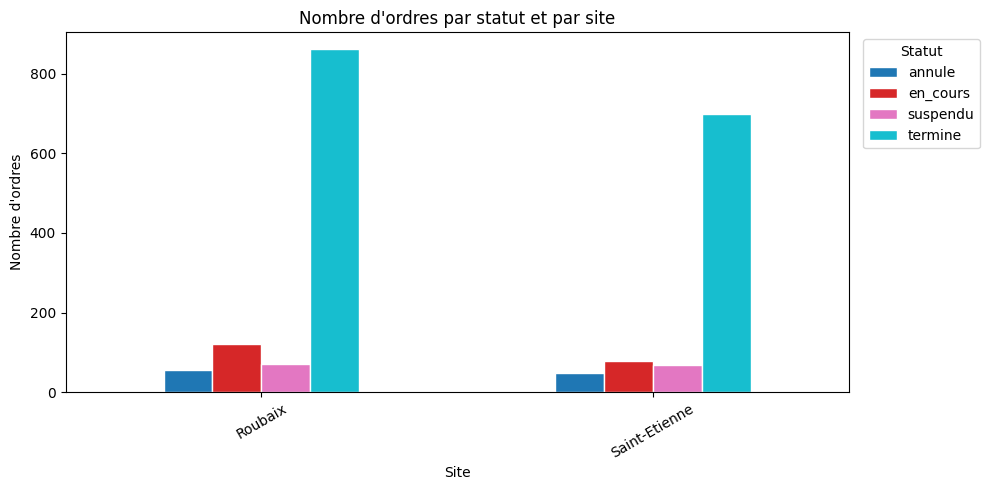

In [173]:

import matplotlib.pyplot as plt

# Graphique : nombre d'occurrences par statut et par site (barres groupées)
pivot = df_erp.groupby(["site", "statut"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white")
ax.set_title("Nombre d'ordres par statut et par site")
ax.set_xlabel("Site")
ax.set_ylabel("Nombre d'ordres")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Statut", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


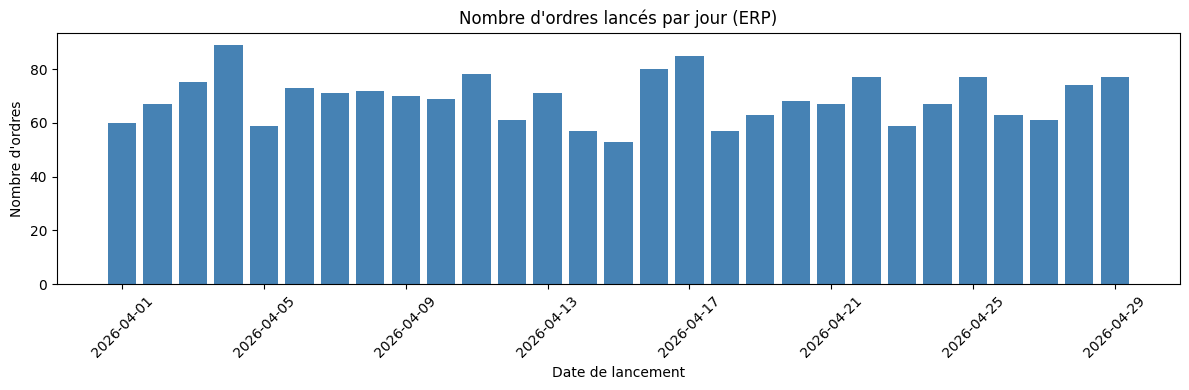

In [189]:

import matplotlib.pyplot as plt

# Histogramme : nombre d'ordres lancés par jour
df_erp["date_lancement_dt"] = pd.to_datetime(df_erp["date_lancement"])
ordres_par_jour = df_erp.set_index("date_lancement_dt").resample("D")["ordre_id"].count()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(ordres_par_jour.index, ordres_par_jour.values, color="steelblue", width=0.8)
ax.set_title("Nombre d'ordres lancés par jour (ERP)")
ax.set_xlabel("Date de lancement")
ax.set_ylabel("Nombre d'ordres")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


,site,n_ouvriers_distincts
0,Roubaix,976
1,Saint-Etienne,806



=== Couverture ouvrier_id par site ===
Roubaix : 1042/1108 renseignés (94.0 %)
Saint-Etienne : 849/892 renseignés (95.2 %)


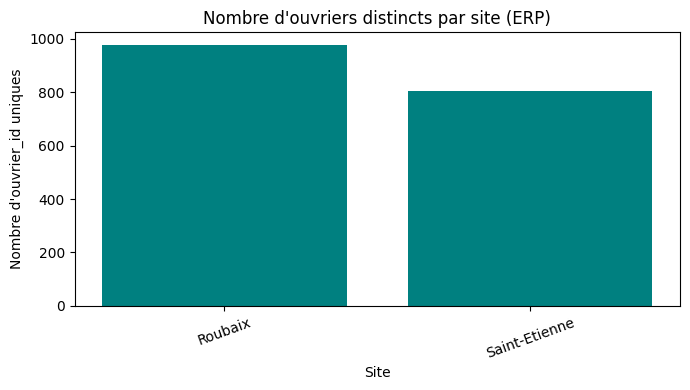

In [204]:

# Analyse : nombre d'ouvriers distincts par site
ouvriers_par_site = (
    df_erp.groupby("site")["ouvrier_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"ouvrier_id": "n_ouvriers_distincts"})
)
display(ouvriers_par_site)

# Taux de couverture (hors valeurs manquantes)
print("\n=== Couverture ouvrier_id par site ===")
for _, row in df_erp.groupby("site"):
    site = row["site"].iloc[0]
    total = len(row)
    renseigne = row["ouvrier_id"].notna().sum()
    print(f"{site} : {renseigne}/{total} renseignés ({renseigne/total*100:.1f} %)")

# Graphique
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ouvriers_par_site["site"], ouvriers_par_site["n_ouvriers_distincts"], color="teal")
ax.set_title("Nombre d'ouvriers distincts par site (ERP)")
ax.set_xlabel("Site")
ax.set_ylabel("Nombre d'ouvrier_id uniques")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


In [218]:

# Tableau : nombre d'ouvriers distincts par site et par line_id
ouvriers_site_line = (
    df_erp.groupby(["site", "line_id"])["ouvrier_id"]
    .nunique()
    .reset_index()
    .rename(columns={"ouvrier_id": "n_ouvriers_distincts"})
    .sort_values(["site", "line_id"])
)
display(ouvriers_site_line)


,site,line_id,n_ouvriers_distincts
0,Roubaix,1,246
1,Roubaix,2,249
2,Roubaix,3,254
3,Roubaix,4,276
4,Saint-Etienne,1,265
5,Saint-Etienne,2,288
6,Saint-Etienne,3,278


> **Analyse du graphique** :
> Les ouvriers sont répartis très uniformément entre les lignes (~246-288 par ligne), ce qui confirme que chaque ouvrier_id n'intervient qu'une à deux fois dans le mois — les identifiants semblent donc non rotatifs (chaque ordre a son propre ouvrier attribué) plutôt que d'être un pool restreint d'employés permanents. À clarifier avec Sébastien.

Ordres Roubaix LINE-3 avec ouvrier renseigné : 258
  dont KO (suspendu/annulé) : 36

Test chi² d'indépendance ouvrier_id × statut KO
  chi² = 258.00, ddl = 253, p-value = 0.4011
  → Pas de corrélation significative (p ≥ 0.05) : les KO sont distribués aléatoirement entre ouvriers.

Ouvriers avec ≥ 2 ordres sur Roubaix LINE-3 : 4


,ouvrier_id,n_ordres,n_ko,taux_ko
161,EMP-6668,2,0,0.0
177,EMP-7313,2,0,0.0
229,EMP-9118,2,0,0.0
238,EMP-9357,2,0,0.0


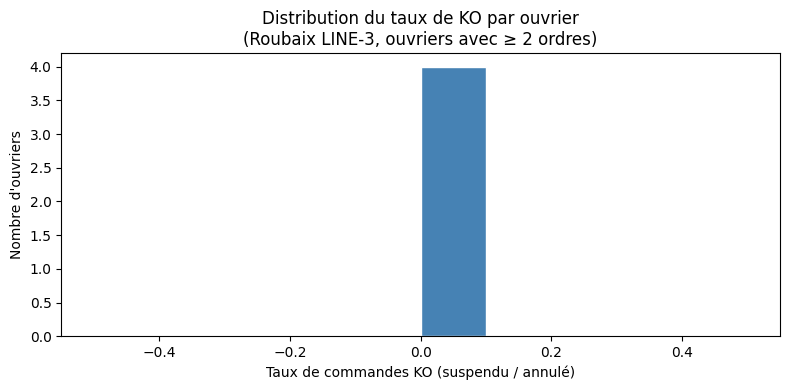

In [231]:

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# --- Roubaix LINE-3 : ordres avec ouvrier_id renseigné ---
df_r3 = df_erp[
    (df_erp["site"] == "Roubaix") &
    (df_erp["line_id"] == 3) &
    (df_erp["ouvrier_id"].notna())
].copy()
df_r3["est_ko"] = df_r3["statut"].isin(["suspendu", "annule"])

print(f"Ordres Roubaix LINE-3 avec ouvrier renseigné : {len(df_r3)}")
print(f"  dont KO (suspendu/annulé) : {df_r3['est_ko'].sum()}")

# --- Test du chi² : indépendance ouvrier_id × statut KO ---
contingency = pd.crosstab(df_r3["ouvrier_id"], df_r3["est_ko"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nTest chi² d'indépendance ouvrier_id × statut KO")
print(f"  chi² = {chi2:.2f}, ddl = {dof}, p-value = {p:.4f}")
if p < 0.05:
    print("  → Corrélation significative (p < 0.05) : certains ouvriers sont davantage associés aux KO.")
else:
    print("  → Pas de corrélation significative (p ≥ 0.05) : les KO sont distribués aléatoirement entre ouvriers.")

# --- Ouvriers avec ≥ 2 ordres sur LINE-3 ---
ouvrier_stats = (
    df_r3.groupby("ouvrier_id")
    .agg(n_ordres=("ordre_id", "count"), n_ko=("est_ko", "sum"))
    .reset_index()
)
ouvrier_stats["taux_ko"] = ouvrier_stats["n_ko"] / ouvrier_stats["n_ordres"]
multi = ouvrier_stats[ouvrier_stats["n_ordres"] >= 2].sort_values("taux_ko", ascending=False)

print(f"\nOuvriers avec ≥ 2 ordres sur Roubaix LINE-3 : {len(multi)}")
if len(multi) > 0:
    display(multi.head(10))

    # Graphique : distribution du taux de KO pour ces ouvriers
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(multi["taux_ko"], bins=10, color="steelblue", edgecolor="white")
    ax.set_title("Distribution du taux de KO par ouvrier\n(Roubaix LINE-3, ouvriers avec ≥ 2 ordres)")
    ax.set_xlabel("Taux de commandes KO (suspendu / annulé)")
    ax.set_ylabel("Nombre d'ouvriers")
    plt.tight_layout()
    plt.show()


> **Analyse du graphique**

> * Le test chi² donne p = 0.40 (largement > 0.05) → les ordres KO (suspendus/annulés) sont distribués aléatoirement entre les ouvriers de Roubaix LINE-3, sans qu'un ouvrier particulier soit davantage associé aux problèmes.
> * Cela se confirme structurellement :
> * Sur 258 ordres (avec ouvrier_id renseigné), seuls 4 ouvriers ont ≥ 2 ordres — et aucun d'eux n'a de KO.
> * La quasi-totalité des ouvriers n'intervient qu'une seule fois sur la ligne, ce qui rend toute corrélation statistiquement impossible à établir.
> * Conclusion : l'ouvrier_id n'est pas un facteur explicatif des KO sur cette ligne. Les anomalies observées (153 emergency_stop) sont plutôt à chercher du côté de la machine elle-même ou du process de production.

> **Observations** :
>
>
> - Volume : 2000 commande (env 1100 sur Roubaix et 800 sur Saitn Etienne)
> - Période : Commande en avril 2026.
> - Qualité observée : Pas de données sur le site de Lyon. Données manquantes sur l'ouvrier_id.
> - Risques RGPD : Risque sur l'ouvrier_id. Cependant avec les données fournies, on ne peut pas identifier un employé.
> - Pertinence métier : Faible sauf si le statut est correlé à un arret suite à une NC.
> - Question pour Sébastien : Que signifie un statut suspendu ou annulé ? Est-ce qu'il y a eu une NC ?

## Source 3 — Logs machines (texte)

In [232]:
log_path = DATA_DIR / "logs_machines.log"
n_lines = sum(1 for _ in log_path.open())
print(f"Nombre de lignes : {n_lines:,}")
print(f"Taille fichier : {log_path.stat().st_size / 1024:.1f} Ko")

# Aperçu des 5 premières lignes
with log_path.open() as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())

Nombre de lignes : 30,000
Taille fichier : 1872.8 Ko
[2026-04-01T00:00:16] Lyon LINE-1 INFO: shift_changed
[2026-04-01T00:01:07] Saint-Etienne LINE-2 INFO: operator_login
[2026-04-01T00:01:34] Saint-Etienne LINE-3 ERROR: vibration_overlimit sensor=SSAI-L3-T01
[2026-04-01T00:04:18] Roubaix LINE-4 INFO: maintenance_completed
[2026-04-01T00:04:35] Lyon LINE-1 INFO: tooling_loaded


In [233]:

import re

# Parsing des logs en DataFrame
pattern = re.compile(
    r'\[(?P<timestamp>.+?)\] (?P<site>\S+) (?P<line>LINE-\d+) (?P<level>INFO|WARN|ERROR): (?P<event>.+)'
)

records = []
with log_path.open() as f:
    for raw in f:
        m = pattern.match(raw.strip())
        if m:
            records.append(m.groupdict())

df_logs = pd.DataFrame(records)
print(f"Lignes parsées : {len(df_logs):,} / {n_lines:,}")

# Statistiques
print("\n=== Répartition par niveau ===")
print(df_logs["level"].value_counts())

print("\n=== Répartition par site ===")
print(df_logs["site"].value_counts())

print("\n=== Répartition par LINE ===")
print(df_logs["line"].value_counts().sort_index())

print("\n=== Top 10 événements ===")
print(df_logs["event"].str.split().str[0].value_counts().head(10))


Lignes parsées : 30,000 / 30,000

=== Répartition par niveau ===
level
INFO     22501
WARN      5758
ERROR     1741
Name: count, dtype: int64

=== Répartition par site ===
site
Saint-Etienne    12041
Roubaix          11970
Lyon              5989
Name: count, dtype: int64

=== Répartition par LINE ===
line
LINE-1    13012
LINE-2     7021
LINE-3     6945
LINE-4     3022
Name: count, dtype: int64

=== Top 10 événements ===
event
operator_login                    4615
maintenance_completed             4501
machine_started                   4488
shift_changed                     4473
tooling_loaded                    4424
vibration_threshold_approached    1443
temperature_drift_detected        1442
lubricant_low                     1440
throughput_below_target           1433
communication_lost                 468
Name: count, dtype: int64


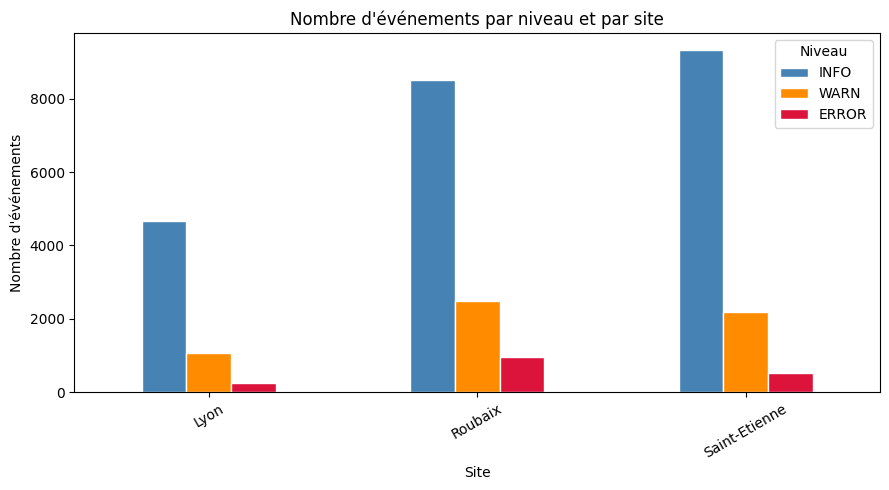

In [234]:

import matplotlib.pyplot as plt

# Graphique 1 : INFO / WARN / ERROR par site
pivot_site = (
    df_logs.groupby(["site", "level"])
    .size()
    .unstack(fill_value=0)
    [["INFO", "WARN", "ERROR"]]
)

colors = {"INFO": "steelblue", "WARN": "darkorange", "ERROR": "crimson"}

fig, ax = plt.subplots(figsize=(9, 5))
pivot_site.plot(kind="bar", ax=ax, color=[colors[c] for c in pivot_site.columns], edgecolor="white")
ax.set_title("Nombre d'événements par niveau et par site")
ax.set_xlabel("Site")
ax.set_ylabel("Nombre d'événements")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Niveau")
plt.tight_layout()
plt.show()


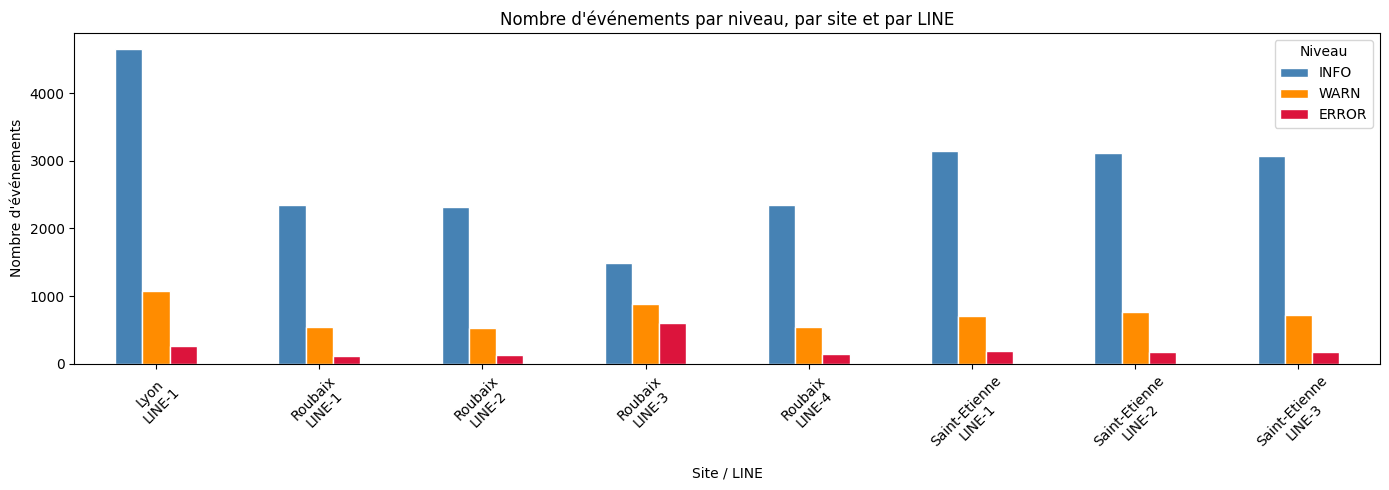

In [235]:

# Graphique 2 : INFO / WARN / ERROR par site et par LINE
df_logs["site_line"] = df_logs["site"] + "\n" + df_logs["line"]

pivot_site_line = (
    df_logs.groupby(["site_line", "level"])
    .size()
    .unstack(fill_value=0)
    [["INFO", "WARN", "ERROR"]]
)

# Trier par site puis ligne
pivot_site_line = pivot_site_line.loc[sorted(pivot_site_line.index)]

fig, ax = plt.subplots(figsize=(14, 5))
pivot_site_line.plot(kind="bar", ax=ax, color=[colors[c] for c in pivot_site_line.columns], edgecolor="white")
ax.set_title("Nombre d'événements par niveau, par site et par LINE")
ax.set_xlabel("Site / LINE")
ax.set_ylabel("Nombre d'événements")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Niveau")
plt.tight_layout()
plt.show()


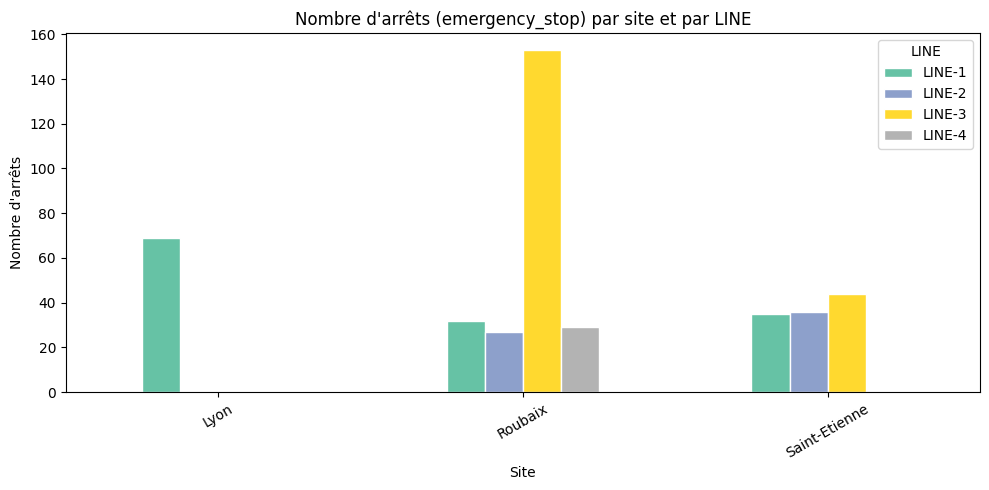

Détail :


line,LINE-1,LINE-2,LINE-3,LINE-4,TOTAL
site,,,,,
Lyon,69,0,0,0,69
Roubaix,32,27,153,29,241
Saint-Etienne,35,36,44,0,115


In [236]:

# Graphique : nombre d'emergency_stop par site et par LINE
df_estop = df_logs[df_logs["event"].str.startswith("emergency_stop")]

pivot_estop = (
    df_estop.groupby(["site", "line"])
    .size()
    .unstack(fill_value=0)
)
pivot_estop = pivot_estop[sorted(pivot_estop.columns)]

fig, ax = plt.subplots(figsize=(10, 5))
pivot_estop.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.set_title("Nombre d'arrêts (emergency_stop) par site et par LINE")
ax.set_xlabel("Site")
ax.set_ylabel("Nombre d'arrêts")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="LINE")
plt.tight_layout()
plt.show()

print("Détail :")
display(pivot_estop.assign(TOTAL=pivot_estop.sum(axis=1)))


> **Observations** :
>
> - Volume : 30K lignes
> - Format : TXT
> - Parsing nécessaire : oui
> - Période : Avril
> - Risques RGPD : non
> - Qualité observée : site de lyon moins représenté. Permet d'avoir les incidents les plus fréquents, les alertes et les problèmes dont les arrets manuel. On voit que la ligne 3 du site de Roubaix a un taux d'incident bien supérieur aux autres.
> - Pertinence métier : Très utile pour analyse les problèmes actuels. On constate que la ligne 3 de Roubaix est fréquemment arretée (bien plus que les autres).
> - Croisement avec les capteurs IoT (corrélation Roubaix line 3 ?) : On peur affectivement croiser les données avec les capteurs de la ligne 3 pour mieux analyser les remontées IOT au moment des incidents.
> - Question pour Sébastien : Depuis quand la ligne 3 du site de roubaix a-t-elle été mise en place ? A-t-elle des spécificités ?


## Corrélation — Roubaix LINE-3 : capteurs IoT × logs ERROR


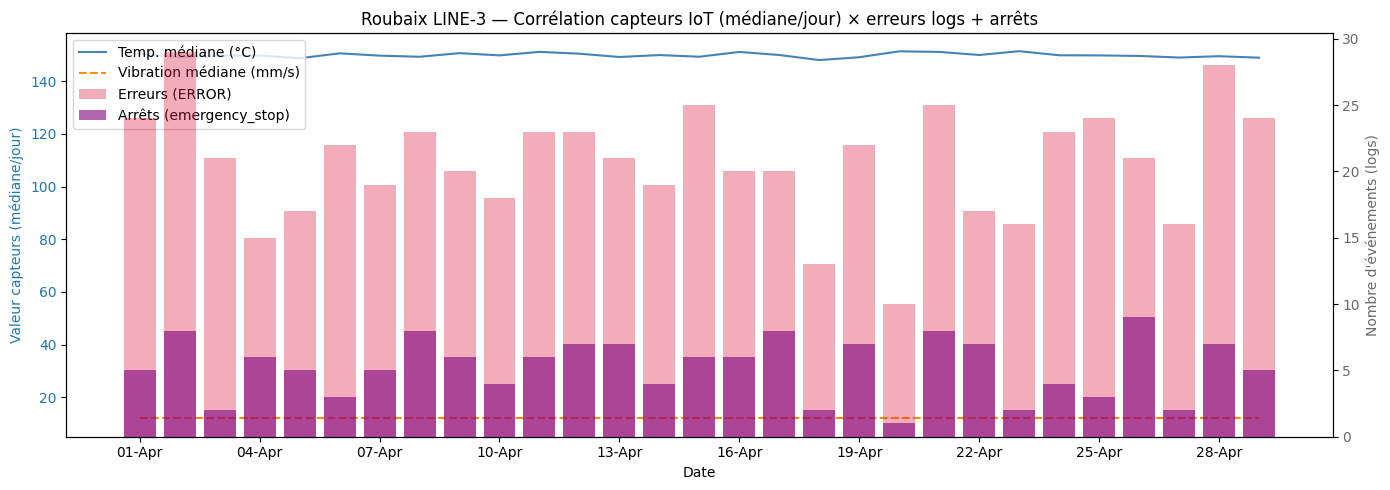

Corrélation (Pearson) entre événements logs et capteurs IoT :
               n_errors   n_estop
temp_med      -0.063947 -0.077355
vibration_med       NaN       NaN
n_errors       1.000000  0.547737
n_estop        0.547737  1.000000


In [237]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Capteurs IoT : Roubaix LINE-3 ---
df_iot_r3 = df_iot[(df_iot["site"] == "Roubaix") & (df_iot["line_id"] == 3)].copy()
df_iot_r3["timestamp"] = pd.to_datetime(df_iot_r3["timestamp"])
iot_daily = df_iot_r3.set_index("timestamp").resample("D").agg(
    temp_med=("temperature_c", "median"),
    vibration_med=("vibration_mms", "median"),
    n_mesures=("sensor_id", "count"),
)

# --- Logs ERROR : Roubaix LINE-3 ---
df_err_r3 = df_logs[
    (df_logs["site"] == "Roubaix") &
    (df_logs["line"] == "LINE-3") &
    (df_logs["level"] == "ERROR")
].copy()
df_err_r3["timestamp"] = pd.to_datetime(df_err_r3["timestamp"])
err_daily = df_err_r3.set_index("timestamp").resample("D").size().rename("n_errors")

# --- emergency_stop : Roubaix LINE-3 ---
df_estop_r3 = df_logs[
    (df_logs["site"] == "Roubaix") &
    (df_logs["line"] == "LINE-3") &
    (df_logs["event"].str.startswith("emergency_stop"))
].copy()
df_estop_r3["timestamp"] = pd.to_datetime(df_estop_r3["timestamp"])
estop_daily = df_estop_r3.set_index("timestamp").resample("D").size().rename("n_estop")

# --- Fusion ---
corr = iot_daily.join(err_daily, how="outer").join(estop_daily, how="outer")
corr[["n_errors", "n_estop"]] = corr[["n_errors", "n_estop"]].fillna(0)

# --- Graphique double-axe ---
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Date")
ax1.set_ylabel("Valeur capteurs (médiane/jour)", color="tab:blue")
ax1.plot(corr.index, corr["temp_med"], color="steelblue", label="Temp. médiane (°C)", linewidth=1.5)
ax1.plot(corr.index, corr["vibration_med"], color="darkorange", linestyle="--", label="Vibration médiane (mm/s)", linewidth=1.5)
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Nombre d'événements (logs)", color="dimgray")
ax2.bar(corr.index, corr["n_errors"], color="crimson", alpha=0.35, width=0.8, label="Erreurs (ERROR)")
ax2.bar(corr.index, corr["n_estop"], color="purple", alpha=0.6, width=0.8, label="Arrêts (emergency_stop)")
ax2.tick_params(axis="y", labelcolor="dimgray")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Roubaix LINE-3 — Corrélation capteurs IoT (médiane/jour) × erreurs logs + arrêts")
plt.tight_layout()
plt.show()

# --- Corrélation statistique ---
print("Corrélation (Pearson) entre événements logs et capteurs IoT :")
print(corr[["temp_med", "vibration_med", "n_errors", "n_estop"]].corr()[["n_errors", "n_estop"]].to_string())



## Corrélation — Roubaix LINE-3 : capteurs IoT × logs WARN


=== Types de WARN Roubaix LINE-3 ===
event
vibration_threshold_approached    237
temperature_drift_detected        229
lubricant_low                     220
throughput_below_target           203
Name: count, dtype: int64


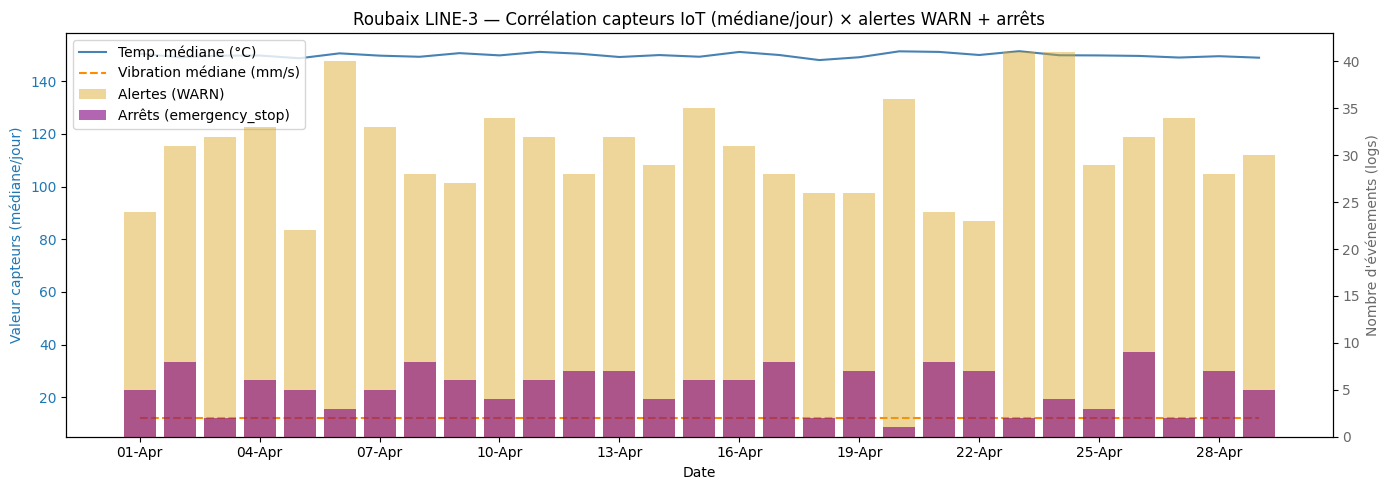


Corrélation (Pearson) entre événements logs et capteurs IoT :
                n_warns   n_estop
temp_med       0.268787 -0.077355
vibration_med       NaN       NaN
n_warns        1.000000 -0.441095
n_estop       -0.441095  1.000000


In [238]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Logs WARN : Roubaix LINE-3 ---
df_warn_r3 = df_logs[
    (df_logs["site"] == "Roubaix") &
    (df_logs["line"] == "LINE-3") &
    (df_logs["level"] == "WARN")
].copy()
df_warn_r3["timestamp"] = pd.to_datetime(df_warn_r3["timestamp"])
warn_daily = df_warn_r3.set_index("timestamp").resample("D").size().rename("n_warns")

# --- Top types d'alertes WARN sur cette ligne ---
print("=== Types de WARN Roubaix LINE-3 ===")
print(df_warn_r3["event"].str.split().str[0].value_counts())

# --- Fusion avec capteurs IoT + emergency_stop ---
corr_warn = iot_daily.join(warn_daily, how="outer").join(estop_daily, how="outer")
corr_warn[["n_warns", "n_estop"]] = corr_warn[["n_warns", "n_estop"]].fillna(0)

# --- Graphique double-axe ---
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Date")
ax1.set_ylabel("Valeur capteurs (médiane/jour)", color="tab:blue")
ax1.plot(corr_warn.index, corr_warn["temp_med"], color="steelblue", label="Temp. médiane (°C)", linewidth=1.5)
ax1.plot(corr_warn.index, corr_warn["vibration_med"], color="darkorange", linestyle="--", label="Vibration médiane (mm/s)", linewidth=1.5)
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Nombre d'événements (logs)", color="dimgray")
ax2.bar(corr_warn.index, corr_warn["n_warns"], color="goldenrod", alpha=0.45, width=0.8, label="Alertes (WARN)")
ax2.bar(corr_warn.index, corr_warn["n_estop"], color="purple", alpha=0.6, width=0.8, label="Arrêts (emergency_stop)")
ax2.tick_params(axis="y", labelcolor="dimgray")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Roubaix LINE-3 — Corrélation capteurs IoT (médiane/jour) × alertes WARN + arrêts")
plt.tight_layout()
plt.show()

# --- Corrélation statistique ---
print("\nCorrélation (Pearson) entre événements logs et capteurs IoT :")
print(corr_warn[["temp_med", "vibration_med", "n_warns", "n_estop"]].corr()[["n_warns", "n_estop"]].to_string())



## Corrélation — Roubaix LINE-3 : emergency_stop (logs) × ordres ERP suspendu / annulé


Ordres KO Roubaix LINE-3 : 37 ({'annule': 20, 'suspendu': 17})
Corrélation Pearson emergency_stop × ordres KO (Roubaix LINE-3) : 0.012


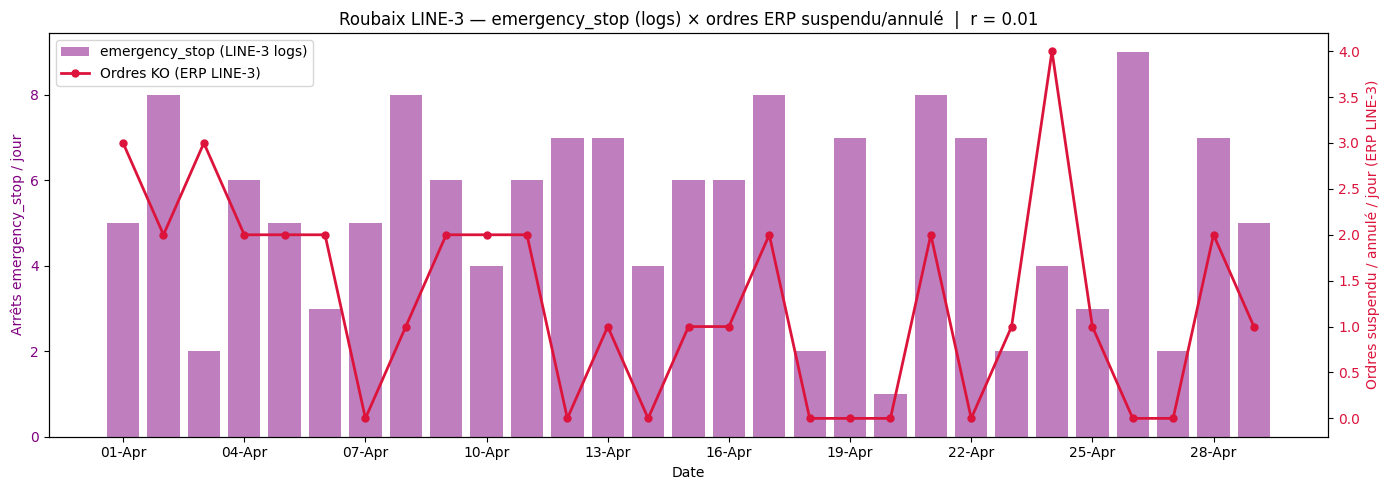

In [239]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- ERP : ordres Roubaix LINE-3 au statut suspendu ou annulé par jour de lancement ---
df_erp_r3_ko = df_erp[
    (df_erp["site"] == "Roubaix") &
    (df_erp["line_id"] == 3) &
    (df_erp["statut"].isin(["suspendu", "annule"]))
].copy()
df_erp_r3_ko["date_lancement_dt"] = pd.to_datetime(df_erp_r3_ko["date_lancement"])
erp_r3_ko_daily = (
    df_erp_r3_ko.set_index("date_lancement_dt")
    .resample("D")["ordre_id"].count()
    .rename("n_ordres_ko")
)
print(f"Ordres KO Roubaix LINE-3 : {len(df_erp_r3_ko)} "
      f"({df_erp_r3_ko['statut'].value_counts().to_dict()})")

# --- emergency_stop : Roubaix LINE-3 (réutilisation de estop_daily) ---
# estop_daily déjà calculé dans la cellule ERROR (Roubaix LINE-3)

# --- Fusion ---
corr_erp = estop_daily.to_frame().join(erp_r3_ko_daily, how="outer").fillna(0)

# --- Corrélation ---
r = corr_erp.corr().loc["n_estop", "n_ordres_ko"]
print(f"Corrélation Pearson emergency_stop × ordres KO (Roubaix LINE-3) : {r:.3f}")

# --- Graphique double-axe ---
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Date")
ax1.set_ylabel("Arrêts emergency_stop / jour", color="purple")
ax1.bar(corr_erp.index, corr_erp["n_estop"],
        color="purple", alpha=0.5, width=0.8, label="emergency_stop (LINE-3 logs)")
ax1.tick_params(axis="y", labelcolor="purple")

ax2 = ax1.twinx()
ax2.set_ylabel("Ordres suspendu / annulé / jour (ERP LINE-3)", color="crimson")
ax2.plot(corr_erp.index, corr_erp["n_ordres_ko"],
         color="crimson", linewidth=2, marker="o", markersize=5, label="Ordres KO (ERP LINE-3)")
ax2.tick_params(axis="y", labelcolor="crimson")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title(f"Roubaix LINE-3 — emergency_stop (logs) × ordres ERP suspendu/annulé  |  r = {r:.2f}")
plt.tight_layout()
plt.show()


> **Observations** :
> Il ne semble pas y avoir de corrélation entre les emergency_stop et les commandes au statut annulé ou suspendu sur la LINE-3 de roubaix.


## Comparaison températures — Roubaix LINE-2 vs LINE-3 (capteurs IoT)


=== Statistiques température (°C) — Roubaix LINE-2 vs LINE-3 ===
        count    mean  median   std     min    max
line                                              
LINE-2   5174   64.90   64.99  8.01   34.36   90.0
LINE-3   5252  149.98  149.88  5.79  140.01  160.0


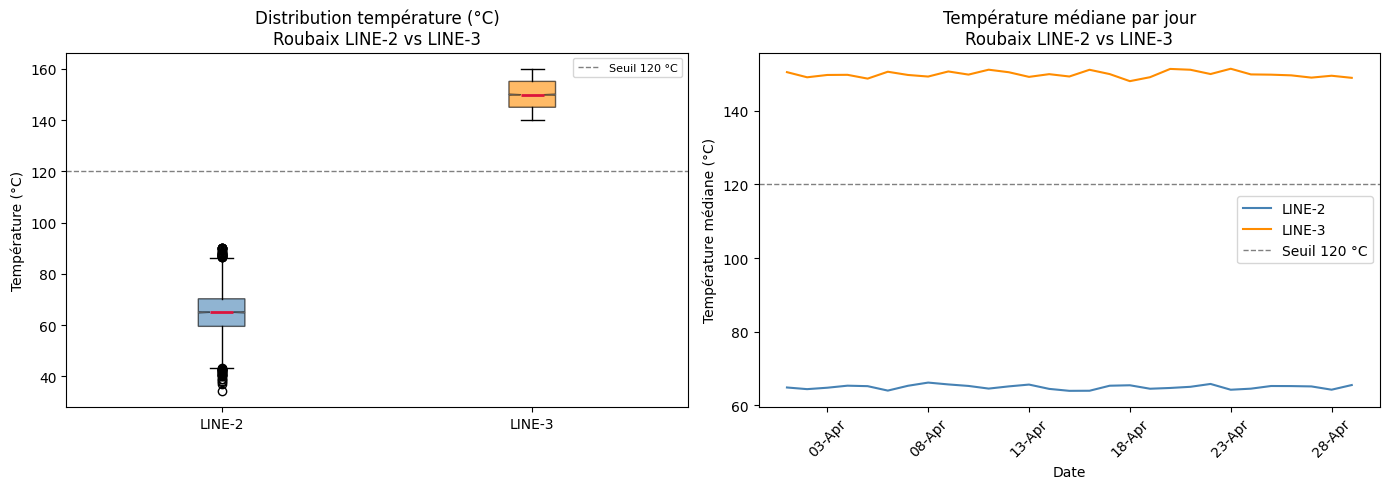

In [240]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# --- Filtrage Roubaix LINE-2 et LINE-3, toutes valeurs conservées ---
df_roubaix_l23 = df_iot[
    (df_iot["site"] == "Roubaix") &
    (df_iot["line_id"].isin([2, 3]))
].copy()
df_roubaix_l23["timestamp"] = pd.to_datetime(df_roubaix_l23["timestamp"])
df_roubaix_l23["line"] = "LINE-" + df_roubaix_l23["line_id"].astype(str)

# --- Statistiques comparatives ---
print("=== Statistiques température (°C) — Roubaix LINE-2 vs LINE-3 ===")
print(df_roubaix_l23.groupby("line")["temperature_c"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boîte à moustaches ---
l2 = df_roubaix_l23[df_roubaix_l23["line"] == "LINE-2"]["temperature_c"]
l3 = df_roubaix_l23[df_roubaix_l23["line"] == "LINE-3"]["temperature_c"]

bp = axes[0].boxplot([l2, l3], tick_labels=["LINE-2", "LINE-3"],
                     patch_artist=True, notch=True,
                     medianprops=dict(color="crimson", linewidth=2))
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("darkorange")
bp["boxes"][1].set_alpha(0.6)
axes[0].set_title("Distribution température (°C)\nRoubaix LINE-2 vs LINE-3")
axes[0].set_ylabel("Température (°C)")
axes[0].axhline(120, color="gray", linestyle="--", linewidth=1, label="Seuil 120 °C")
axes[0].legend(fontsize=8)

# --- Évolution de la médiane journalière ---
temp_daily = (
    df_roubaix_l23.groupby(["line", pd.Grouper(key="timestamp", freq="D")])["temperature_c"]
    .median()
    .reset_index()
)
for line, color in [("LINE-2", "steelblue"), ("LINE-3", "darkorange")]:
    sub = temp_daily[temp_daily["line"] == line]
    axes[1].plot(sub["timestamp"], sub["temperature_c"],
                 label=line, color=color, linewidth=1.5)
axes[1].axhline(120, color="gray", linestyle="--", linewidth=1, label="Seuil 120 °C")
axes[1].set_title("Température médiane par jour\nRoubaix LINE-2 vs LINE-3")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Température médiane (°C)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=5))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


> **Observations** :
> LINE-3 fonctionne systématiquement entre 140 et 160 °C sur tout le mois d'avril, soit plus de 2× la température de LINE-2. Ce n'est pas du tout un problème de capteur aberrant — c'est une réalité physique de la ligne.
> Cela explique directement les 153 emergency_stop : une ligne opérant en permanence à la limite haute de son enveloppe thermique est mécaniquement beaucoup plus sujette aux arrêts d'urgence. 
> Question clé pour Sébastien : quelle est la température nominale de fonctionnement de LINE-3 ? Est-ce un régime normal ou une dérive ?


## Comparaison vibrations — Roubaix LINE-2 vs LINE-3 (capteurs IoT)


=== Statistiques vibration (mm/s) — Roubaix LINE-2 vs LINE-3 ===
        count    mean  median    std   min     max
line                                              
LINE-2   5116   4.027   4.037  1.198   0.0   8.875
LINE-3   5194  12.000  12.000  0.000  12.0  12.000


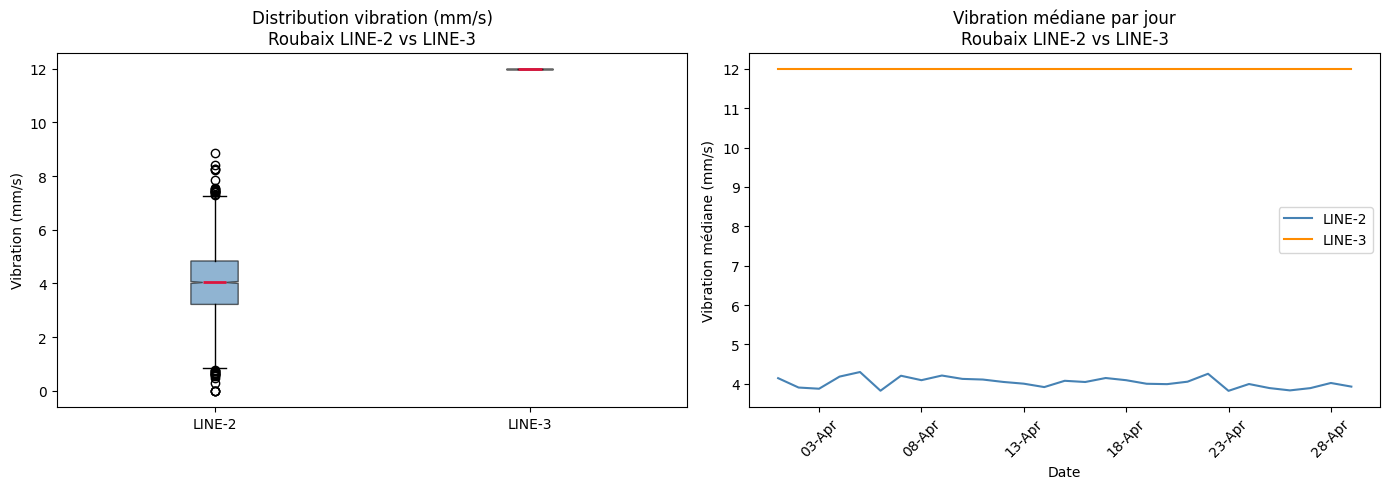

In [241]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# df_roubaix_l23 déjà calculé (Roubaix LINE-2 & LINE-3, timestamps parsés)
# Exclusion des NaN sur vibration_mms
vib = df_roubaix_l23.dropna(subset=["vibration_mms"])

# --- Statistiques ---
print("=== Statistiques vibration (mm/s) — Roubaix LINE-2 vs LINE-3 ===")
print(vib.groupby("line")["vibration_mms"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boîte à moustaches ---
v2 = vib[vib["line"] == "LINE-2"]["vibration_mms"]
v3 = vib[vib["line"] == "LINE-3"]["vibration_mms"]

bp = axes[0].boxplot([v2, v3], tick_labels=["LINE-2", "LINE-3"],
                     patch_artist=True, notch=True,
                     medianprops=dict(color="crimson", linewidth=2))
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("darkorange")
bp["boxes"][1].set_alpha(0.6)
axes[0].set_title("Distribution vibration (mm/s)\nRoubaix LINE-2 vs LINE-3")
axes[0].set_ylabel("Vibration (mm/s)")

# --- Évolution de la médiane journalière ---
vib_daily = (
    vib.groupby(["line", "timestamp"])["vibration_mms"]
    .median()
    .reset_index()
)
# Résample par jour
import pandas as pd
vib_daily_resamp = (
    vib.groupby(["line", pd.Grouper(key="timestamp", freq="D")])["vibration_mms"]
    .median()
    .reset_index()
)
for line, color in [("LINE-2", "steelblue"), ("LINE-3", "darkorange")]:
    sub = vib_daily_resamp[vib_daily_resamp["line"] == line]
    axes[1].plot(sub["timestamp"], sub["vibration_mms"],
                 label=line, color=color, linewidth=1.5)

axes[1].set_title("Vibration médiane par jour\nRoubaix LINE-2 vs LINE-3")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Vibration médiane (mm/s)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=5))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


> **Observations** :
> LINE-3 est bloquée à exactement 12.0 mm/s en permanence — écart-type de 0, valeur constante sur tout le mois. 
> Ceci est la valeur maximale du capteur (max = 12.0). Le capteur de vibration de LINE-3 est saturé : il a atteint sa limite de mesure et ne peut plus distinguer les niveaux de vibration réels.
> Combiné à la température constamment entre 140-160 °C, LINE-3 présente deux capteurs en anomalie critique, ce qui explique les 153 arrêts d'urgence. 
> C'est le signal le plus fort du notebook à remonter à Sébastien.


## Comparaison débits — Roubaix LINE-2 vs LINE-3 (capteurs IoT)


=== Statistiques débit (µh) — Roubaix LINE-2 vs LINE-3 ===
        count    mean  median    std   min    max
line                                             
LINE-2   5174  109.69  109.56  11.57  80.0  150.0
LINE-3   5252  110.05  109.89  11.97  80.0  150.0


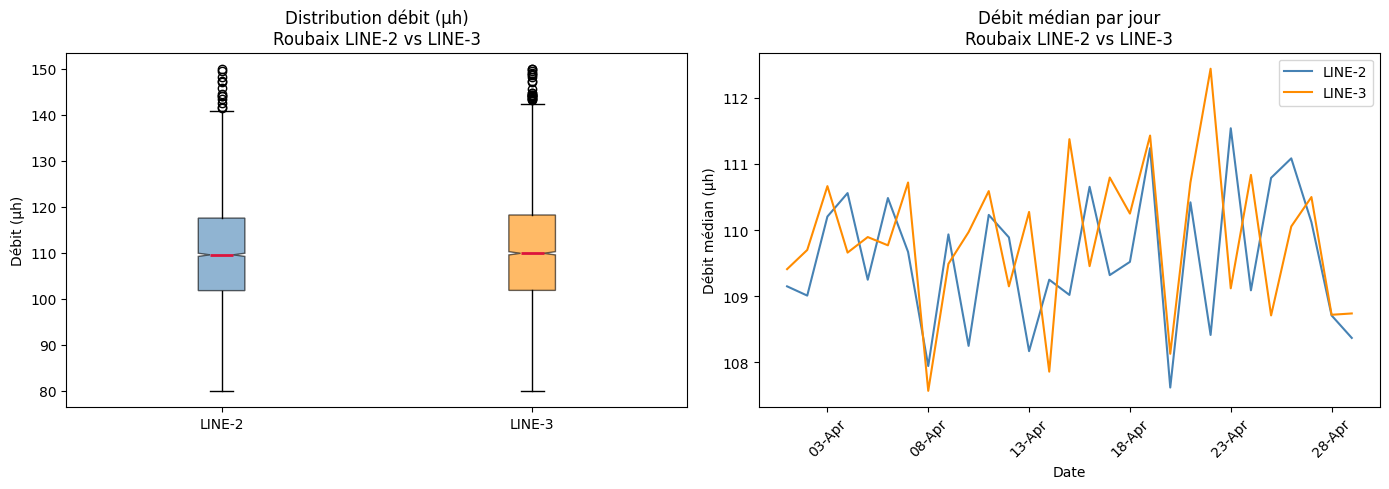

In [242]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# df_roubaix_l23 déjà disponible (Roubaix LINE-2 & LINE-3, timestamps parsés)

# --- Statistiques ---
print("=== Statistiques débit (µh) — Roubaix LINE-2 vs LINE-3 ===")
print(df_roubaix_l23.groupby("line")["debit_uh"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boîte à moustaches ---
d2 = df_roubaix_l23[df_roubaix_l23["line"] == "LINE-2"]["debit_uh"]
d3 = df_roubaix_l23[df_roubaix_l23["line"] == "LINE-3"]["debit_uh"]

bp = axes[0].boxplot([d2, d3], tick_labels=["LINE-2", "LINE-3"],
                     patch_artist=True, notch=True,
                     medianprops=dict(color="crimson", linewidth=2))
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("darkorange")
bp["boxes"][1].set_alpha(0.6)
axes[0].set_title("Distribution débit (µh)\nRoubaix LINE-2 vs LINE-3")
axes[0].set_ylabel("Débit (µh)")

# --- Évolution de la médiane journalière ---
debit_daily = (
    df_roubaix_l23.groupby(["line", pd.Grouper(key="timestamp", freq="D")])["debit_uh"]
    .median()
    .reset_index()
)
for line, color in [("LINE-2", "steelblue"), ("LINE-3", "darkorange")]:
    sub = debit_daily[debit_daily["line"] == line]
    axes[1].plot(sub["timestamp"], sub["debit_uh"],
                 label=line, color=color, linewidth=1.5)

axes[1].set_title("Débit médian par jour\nRoubaix LINE-2 vs LINE-3")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Débit médian (µh)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=5))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


> **Observations** :
> Les distributions sont quasi-identiques et les courbes journalières évoluent en parallèle. Le débit n'est pas le facteur discriminant entre LINE-2 et LINE-3.

## Synthèse pour `identification_sources.md`

Remplis le tableau d'inventaire dans `../identification_sources.md` à
partir des observations ci-dessus.

Synthèse des 3 capteurs pour LINE-3 Roubaix :

* Débit : ✅ normal, identique à LINE-2
* Température : ⚠️ systématiquement entre 140-160 °C (vs 35-90 °C pour LINE-2)
* Vibration : 🔴 capteur saturé à 12 mm/s en permanence (valeur max)

Le problème de LINE-3 est clairement thermique et mécanique, pas lié au débit.